# Set Atomic unit system

In [1]:
import atomic_units as au

hb=1.0
m0=8.8
kappa0=2.3 # 4*pi*epsilon0
e0=3.4
dx=0.05

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))

0.007297352569307101 dimensionless
0.12240749165941847 electron_volt
2.340527796123471 nanometer
0.11702638980617355 nanometer


# Set unified grid

In [2]:
import numpy as np

uxgrid_num = 18*1024
uxgrid_dx = dx
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.05
921.6
2157.030416907391 nanometer


In [3]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,\
                            mass = unit_sys.me)

#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

In [4]:

print((10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude)
print(unit_sys.length_unit)

0.22609311104120788
2.340527796123471e-09 meter


-3.49 electron_volt 0.12240749165941847 electron_volt
-28.511326820669044
0.9600000000000001 electron_volt 0.12240749165941847 electron_volt
7.8426572343387635
0.12240749165941847
0.22609311104120788
384.52865267852684


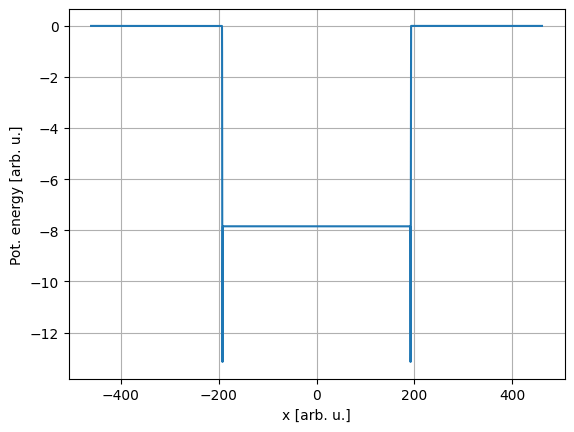

In [5]:
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import pint

ureg = unit_sys.ureg

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83*ureg.volt #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Al_in_V=-1.66*ureg.volt 
standard_potential_of_Ir_in_V=0.87*ureg.volt #standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246*ureg.volt # standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

wall_in_V = standard_potential_of_Al_in_V-standard_potential_of_Au_in_V
wall_in_eV = (wall_in_V*ureg("elementary_charge").to("C")).to("eV")
wall_in_unit_sys = (wall_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(wall_in_eV,unit_sys.energy_unit.to("eV"))
print(wall_in_unit_sys)

well_in_V = standard_potential_of_Au_in_V-standard_potential_of_Ir_in_V
well_in_eV = (well_in_V*ureg("elementary_charge").to("C")).to("eV")
well_in_unit_sys = (well_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(well_in_eV,unit_sys.energy_unit.to("eV"))
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = (10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude
print(wall_width)
well_width = 900/length_unit_in_nm
print(well_width)

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 2,\
                                   wellfall = 2)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


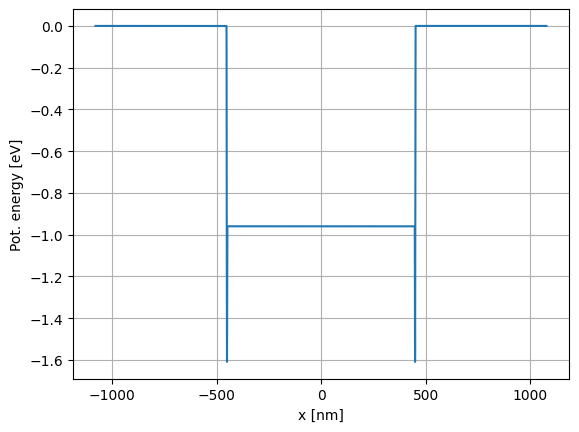

In [6]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

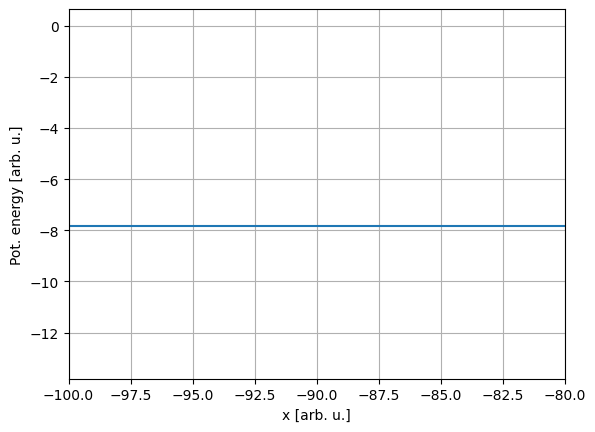

In [7]:
plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-100, -80])
plt.grid()
plt.show()

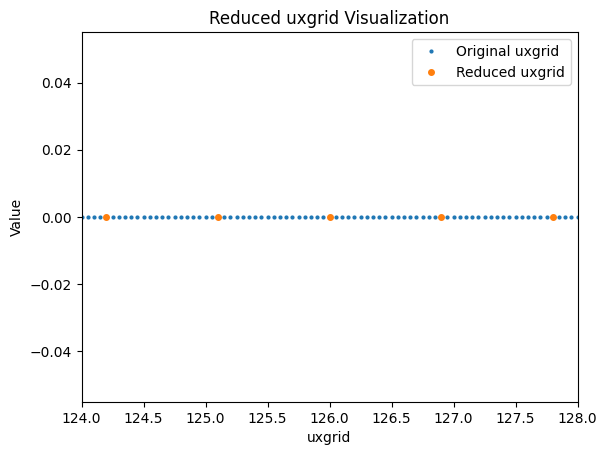

Original uxgrid length: 18432
Reduced uxgrid length: 1024


In [8]:
# Desired number of points
desired_points = 1024

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [9]:
# Highlighted ranges
highlight_ranges = [(-121, -119), (119, 121)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 18432
Number of highlighted points: 80


In [10]:
mask += mask_highlight_ranges

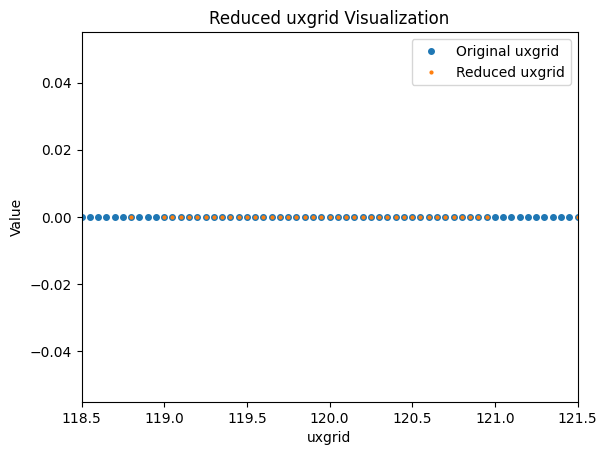

Original uxgrid length: 18432
Reduced uxgrid length: 1100


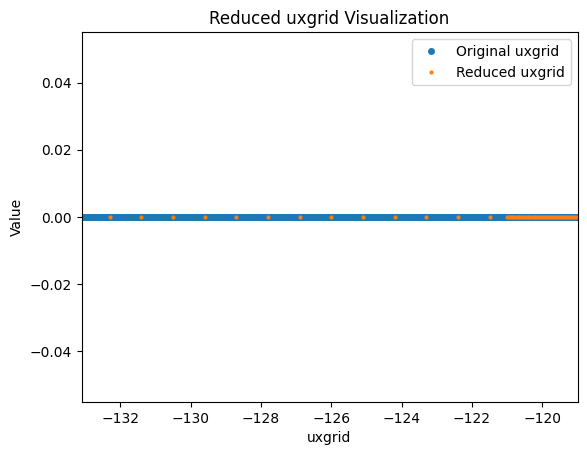

Original uxgrid length: 18432
Reduced uxgrid length: 1100


In [11]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute eigen states

In [12]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
constpot=pots.ConstantPotential(uxgrid, 1.0)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [13]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 6,which = 'SR')

print(eigenvalues[0])

-11.997653661411924


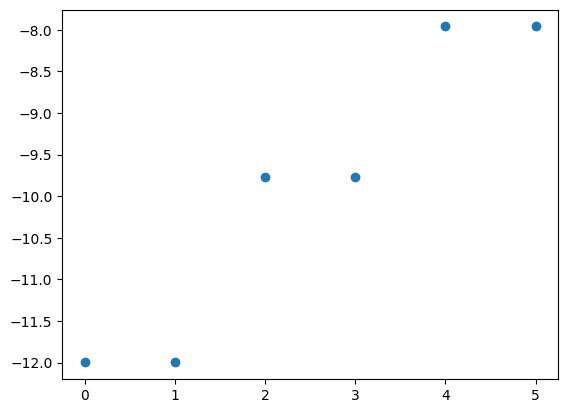

In [14]:
plt.scatter(np.arange(6),eigenvalues)

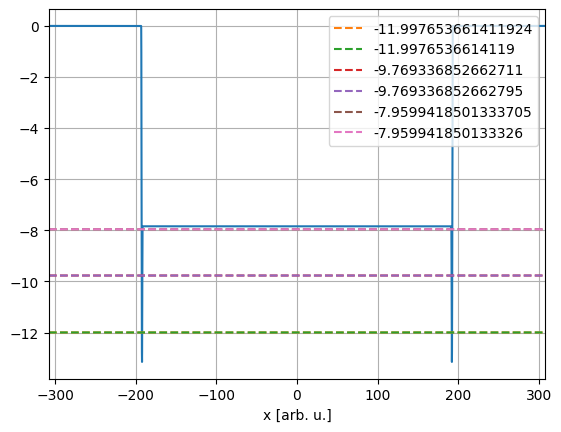

In [15]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    #plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

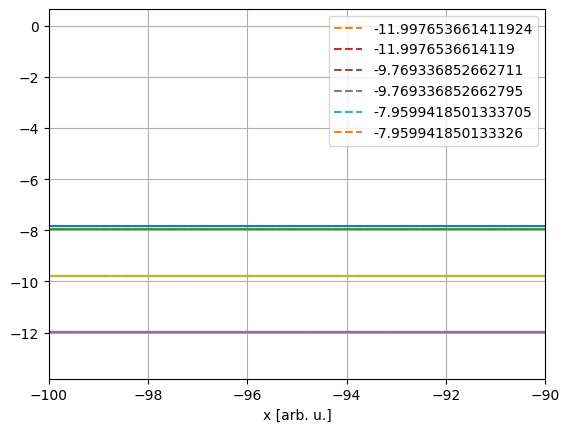

In [16]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(-520000,-480000)
plt.xlim(-100,-90)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [17]:
t_vals=[]
r_vals=[]

energy_min = 5.4
energy_max = 5.6

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.energy2k(energy_min_in_unit_sys)
k_max = dispersion.energy2k(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,11)

print(k_min,k_max,k_vals)

e_vals=[]

# quasiparticles=[]

# eigen_states_pk=[]
# eigen_states_mk=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.k2energy(k)
    e_vals.append(ein)

    #inistate_pk, inistate_mk = getIniStates(Ein,uxgrid,modelpot)
    # state_pk_norm, state_mk_norm = trat.normed_states_at_given_energy(ein,kin,ham_static)
    # eigen_states_pk.append(state_pk_norm)
    # eigen_states_mk.append(state_mk_norm)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    #trans,refl = get_t_and_r(Ein,uxgrid,uxgrid_dx,inistate_pk)
    #trans,refl = trat.transmission(kin,state_pk_norm),trat.reflexion(kin,state_pk_norm)

    t_vals.append(qp_pk['transmission'])
    r_vals.append(qp_pk['reflection'])

    print(kin)

    num=len(t_vals)

    # plt.plot(k_vals[:num],t_vals,"-o",label="T")
    # plt.plot(k_vals[:num],r_vals,"-o",label="R")
    # plt.xlabel("k [arb. u.]")
    # #plt.ylabel("Coefficient")
    # plt.legend()
    # plt.grid()
    # plt.show()

30.826417833609003 31.545414342004676 [30.82641783 30.89831748 30.97021714 31.04211679 31.11401644 31.18591609
 31.25781574 31.32971539 31.40161504 31.47351469 31.54541434]


KeyboardInterrupt: 

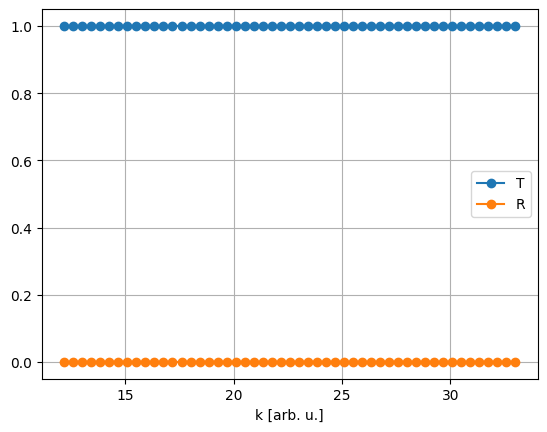

In [33]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

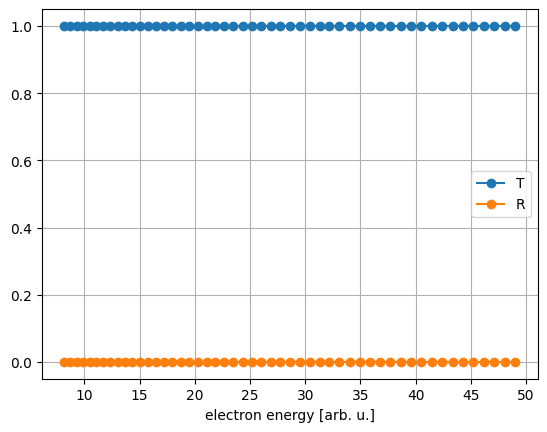

In [34]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

In [17]:
t_vals=[]
r_vals=[]

energy_min = 1.0
energy_max = 6.0

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.energy2k(energy_min_in_unit_sys)
k_max = dispersion.energy2k(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,51)

print(k_min,k_max,k_vals)

e_vals=[]

# quasiparticles=[]

# eigen_states_pk=[]
# eigen_states_mk=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.k2energy(k)
    e_vals.append(ein)

    #inistate_pk, inistate_mk = getIniStates(Ein,uxgrid,modelpot)
    # state_pk_norm, state_mk_norm = trat.normed_states_at_given_energy(ein,kin,ham_static)
    # eigen_states_pk.append(state_pk_norm)
    # eigen_states_mk.append(state_mk_norm)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    #trans,refl = get_t_and_r(Ein,uxgrid,uxgrid_dx,inistate_pk)
    #trans,refl = trat.transmission(kin,state_pk_norm),trat.reflexion(kin,state_pk_norm)

    t_vals.append(qp_pk['transmission'])
    r_vals.append(qp_pk['reflection'])

    print(kin)

12.178183144730632 32.98484255313284 [12.17818314 12.59431633 13.01044952 13.42658271 13.8427159  14.25884909
 14.67498227 15.09111546 15.50724865 15.92338184 16.33951503 16.75564821
 17.1717814  17.58791459 18.00404778 18.42018097 18.83631416 19.25244734
 19.66858053 20.08471372 20.50084691 20.9169801  21.33311328 21.74924647
 22.16537966 22.58151285 22.99764604 23.41377923 23.82991241 24.2460456
 24.66217879 25.07831198 25.49444517 25.91057835 26.32671154 26.74284473
 27.15897792 27.57511111 27.9912443  28.40737748 28.82351067 29.23964386
 29.65577705 30.07191024 30.48804342 30.90417661 31.3203098  31.73644299
 32.15257618 32.56870936 32.98484255]
0.038463353210253855 3.849512200341126e-05
12.178183144730632
0.03735682744230185 5.066864704255069e-05
12.594316332898677
0.0363274735444624 6.0266696088226224e-06
13.01044952106672
0.03536822580359018 6.9320188675169194e-06
13.426582709234765
0.03447287320376666 2.165760696051446e-05
13.842715897402808
0.03363593488586363 1.70714993973193

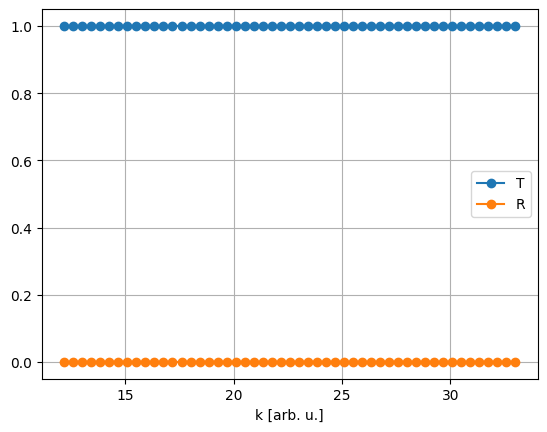

In [35]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

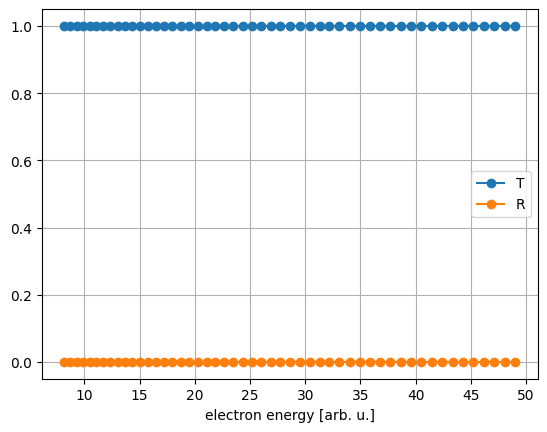

In [36]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [18]:
t_start=0
t_stop=1000.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.05
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

20000


In [19]:
spot_size_nm = 800 # in nm
magnitude_of_electric_field_vm = 1.0 # in GV/m
central_wavelength_nm = 800 # in nm

In [20]:
central_wavelength = central_wavelength_nm*unit_sys.convert_length_from("nm")
print(central_wavelength)

omega = 2*np.pi*unit_sys.speed_of_light/central_wavelength_nm
print(omega)
num_of_cycles = 5 # one cycle is around 2.66 fs

t_min = 0
t_max = num_of_cycles*2*np.pi/omega
print("pulse length hus:",t_max,t_max*unit_sys.time_unit.to("fs"))

s_min = -0.5*spot_size_nm*unit_sys.convert_length_from("nm")
s_max = 0.5*spot_size_nm*unit_sys.convert_length_from("nm")
print("spot size:",s_min,s_max)


magnitude = magnitude_of_electric_field_vm*unit_sys.convert_electric_field_from("GV/m")
print(magnitude)

beta=0.2

laserpot = pots.SmoothLaserPotential(uxgrid, spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

laserpot_masked = pots.SmoothLaserPotential(uxgrid[mask], spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

print(laserpot.omega0)

341.8032468253572
5.409467923108539
pulse length hus: 5.807581629552364 31.228641464002013 femtosecond
spot size: -170.9016234126786 170.9016234126786
5.623761413124601
5.409467923108539


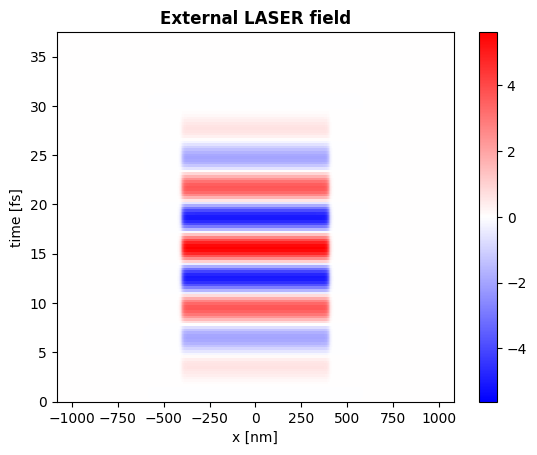

In [21]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)
X_nm,Y_fs = np.meshgrid(uxgrid[mask]*unit_sys.length_unit.to('nm').magnitude,\
                  utgrid*unit_sys.time_unit.to('fs').magnitude)

Z=laserpot_masked(Y)

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X_nm, Y_fs, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('External LASER field', fontweight ="bold")
plt.ylim(0.0,1.2*laserpot.temporal_max*unit_sys.time_unit.to('fs').magnitude)
#plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
plt.xlabel("x [nm]")
plt.ylabel("time [fs]")
plt.show()

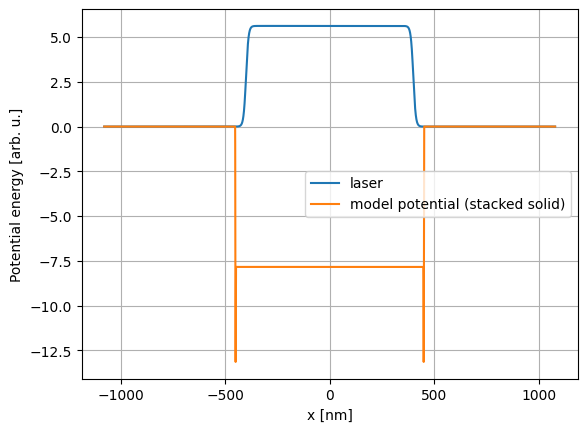

In [22]:
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          laserpot(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          modelpot(uxgrid),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

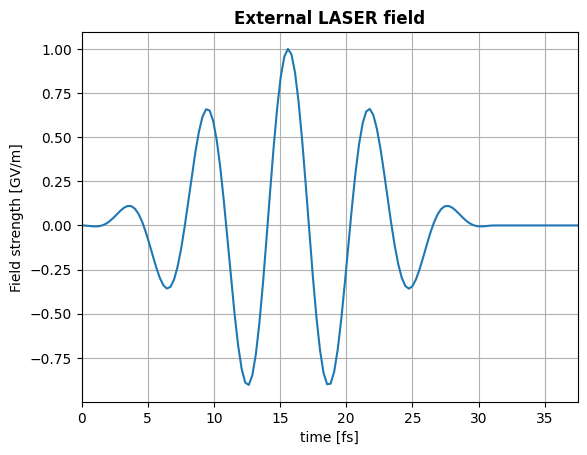

In [23]:
plt.plot(utgrid*unit_sys.time_unit.to('fs').magnitude,\
          laserpot.value_at(0.0,utgrid)*unit_sys.electric_field_unit.to('GV/m'),\
          label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [GV/m]")
plt.title('External LASER field', fontweight ="bold")
plt.xlim(0,1.2*laserpot.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

# Vcap check

## Advanced methode

In [24]:
from quantum_toolkit import quantum_transport_toolkit as trat

ein=3.0*unit_sys.convert_energy_from('eV')
print(ein)
kin=dispersion.energy2k(ein)
print(kin)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=False)

24.508303857308633
21.837608491652393


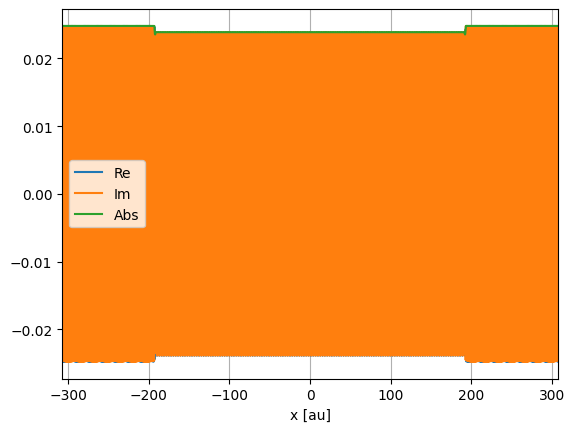

In [25]:
#plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

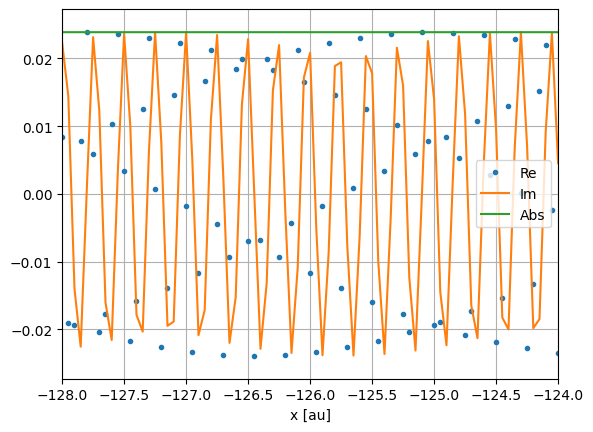

In [26]:
#plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),'.',label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-128, -124])
plt.legend()
plt.grid()
plt.show()

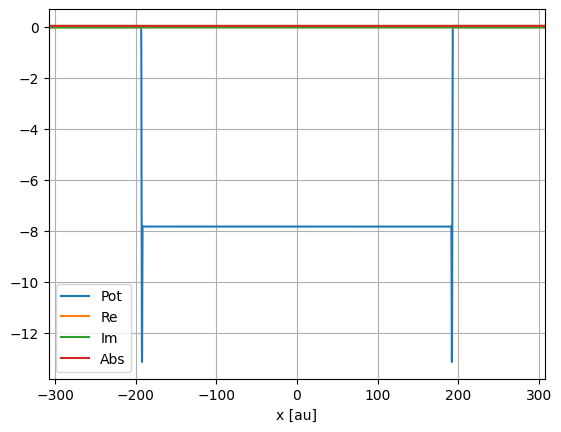

In [27]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

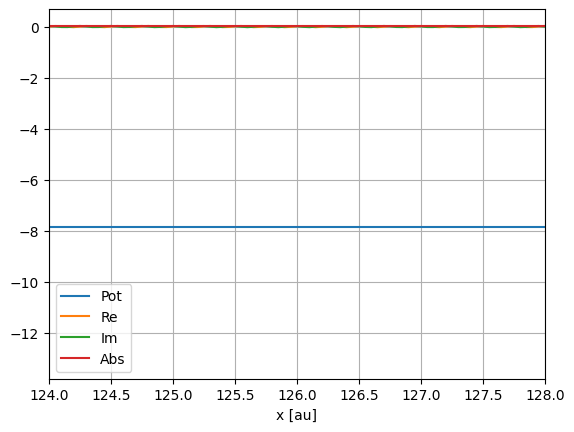

In [28]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([124, 128])
plt.legend()
plt.grid()
plt.show()

In [29]:
v_cap=quat.vcap_generator(uxgrid,param_x0=350,param_lambda0 = 0.05)

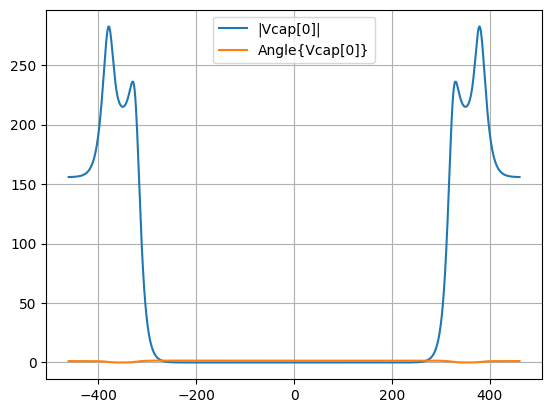

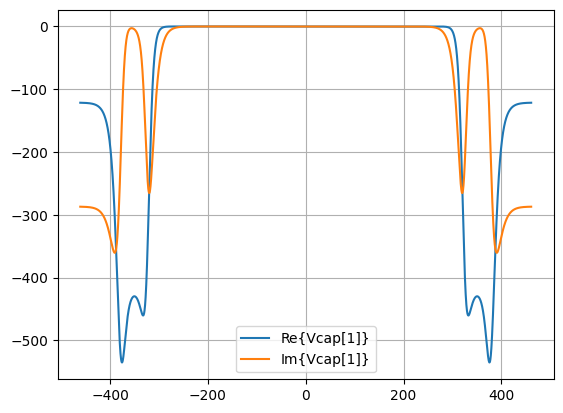

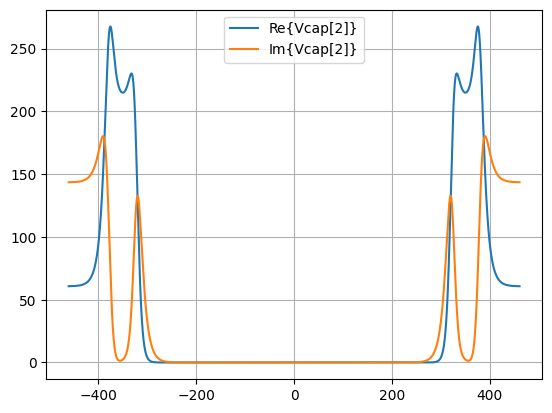

In [30]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

# Masked

In [31]:
masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

masked_psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

In [32]:
masked_psi_pk_te.run()

KeyboardInterrupt: 

In [ ]:
masked_psi_mk_te.run()

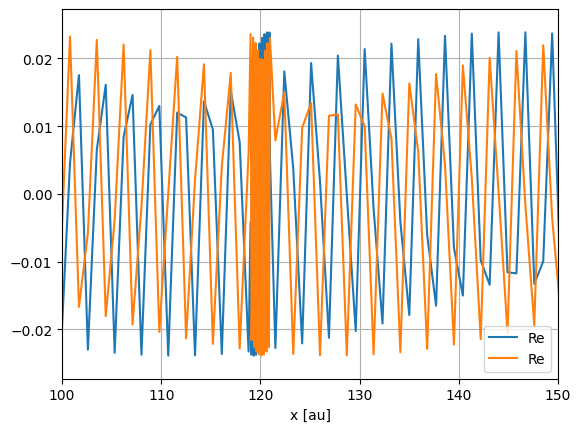

In [ ]:
plt.plot(uxgrid[mask],np.real(masked_psi_pk_te.psi_time_evolution["value"][:,0]),label="Re")
plt.plot(uxgrid[mask],np.real(masked_psi_pk_te.psi_time_evolution["value"][:,150]),label="Re")
plt.xlabel("x [au]")
plt.xlim([100, 150])
plt.legend()
plt.grid()
plt.show()

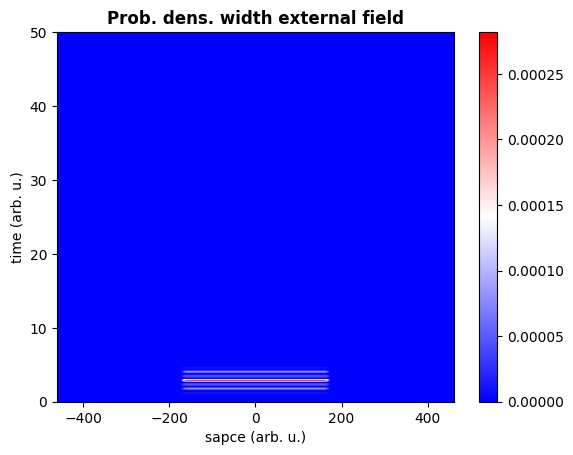

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution["value"]))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-110, 110])
plt.ylim([0,50])
plt.show()

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution["value"]))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-12) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-350, 350])
#plt.ylim([0,50])
plt.show()

NameError: name 'np' is not defined

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
#plt.ylim(2*laserpot.temporal_width,1200)#2*laserpot_cep0.temporal_width)
plt.show()

OverflowError: cannot convert float infinity to integer

<Figure size 640x480 with 2 Axes>

# Compute probability current

In [ ]:
# choose masurement points on the right and the left side
meas_point_right=105
meas_point_left=-meas_point_right

In [ ]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

7116 11316
-104.99999999991911 105.00000000012864


In [ ]:
pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:1238: RuntimeWarning: overflow encountered in divide
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home/magashegyi/syncthing/Munka/Wigner/NEGF/code/python/git_test/quantum_toolkit/quantum_toolkit.py:103: RuntimeWarning: overflow encountered in multiply
  return np.imag(np.conj(state["value"]) * np.gradient(state["value"],dx,axis=0))
/home/magashegyi/syncthing/Munka/Wigner/NEGF/code/python/git_test/quantum_toolkit/quantum_toolkit.py:103: RuntimeWarning: invalid value encountered in multiply
  return np.imag(np.conj(state["value"]) * np.gradient(state["value"],dx,axis=0))
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:1238: RuntimeWarning: overflow encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:1238: RuntimeWarning: invalid value encountered in divide
  

In [ ]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

IndexError: index 7116 is out of bounds for axis 0 with size 1100

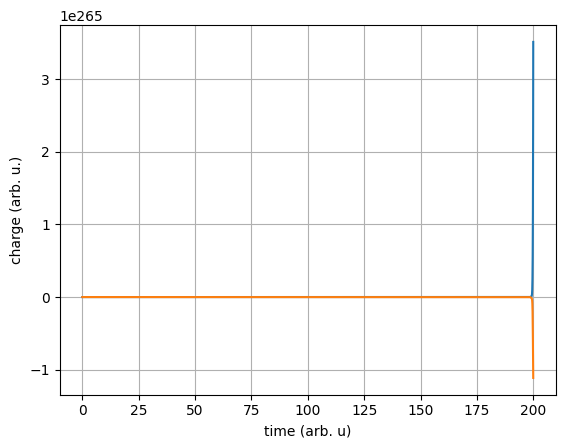

In [ ]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [ ]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

/tmp/ipykernel_76370/1507531803.py:4: RuntimeWarning: invalid value encountered in add
  masked_pc2_sum=masked_pc2_pk+masked_pc2_mk


In [ ]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-105.19999999997736 104.80000000007038


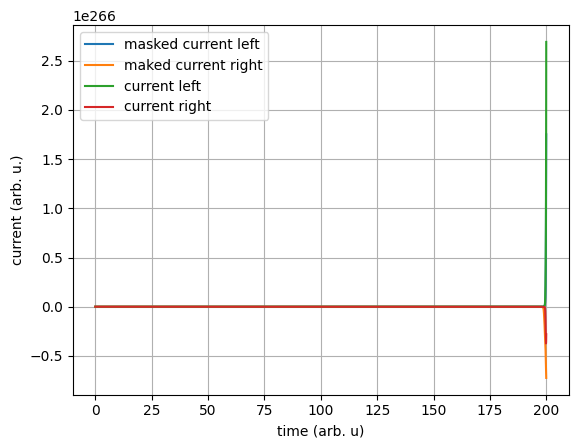

In [ ]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

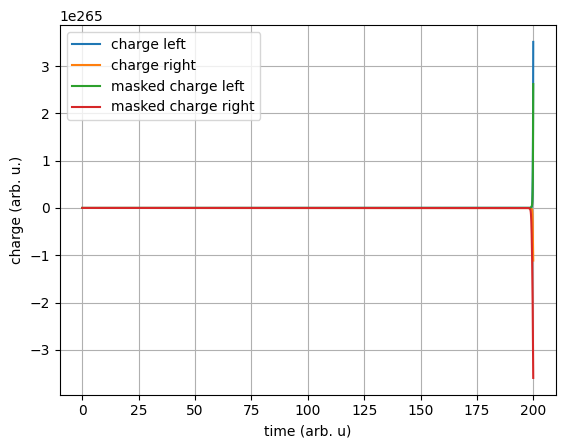

In [ ]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from itertools import product
import io

# Paraméterek definiálása
param_ranges = {
    "electron_energy": np.linspace(1, 5, 5),  # Elektron energiák (eV)
    "pulse_width": np.linspace(50, 200, 4),  # Lézer impulzus szélességek (fs)
    "pulse_frequency": np.linspace(0.5, 2.0, 4)  # Lézer frekvenciák (PHz)
}

# HDF5 fájl létrehozása az eredmények tárolására
output_file = "simulation_results.h5"
with h5py.File(output_file, "w") as hdf:
    # Paraméterkombinációk iterálása
    for electron_energy, pulse_width, pulse_frequency in product(
        param_ranges["electron_energy"],
        param_ranges["pulse_width"],
        param_ranges["pulse_frequency"]
    ):
        # Szimuláció futtatása (helyettesítsd a saját szimulációs kódoddal)
        time = np.linspace(0, 100, 1000)  # Időtengely (fs)
        signal = np.sin(2 * np.pi * pulse_frequency * time) * np.exp(-time / pulse_width)

        # Eredmények mentése HDF5-be
        group_name = f"energy_{electron_energy}_width_{pulse_width}_freq_{pulse_frequency}"
        group = hdf.create_group(group_name)
        group.create_dataset("time", data=time)
        group.create_dataset("signal", data=signal)

        # Ábra mentése HDF5-be
        fig, ax = plt.subplots()
        ax.plot(time, signal, label=f"E={electron_energy} eV, W={pulse_width} fs, F={pulse_frequency} PHz")
        ax.set_xlabel("Time (fs)")
        ax.set_ylabel("Signal")
        ax.set_title("Simulation Result")
        ax.legend()
        ax.grid()

        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        group.create_dataset("plot", data=np.frombuffer(buf.getvalue(), dtype='uint8'))
        plt.close(fig)

print(f"Simulation results saved to {output_file}")

Simulation results saved to simulation_results.h5
